# Problem Set 02: Bank Marketing — Term Deposit Prediction via Logistic Regression

## Problem Context & Motivation

**Objective:** Predict whether a banking customer will subscribe to a term deposit using historical campaign data.

**Dataset:** UCI Bank Marketing Data Set (`bank-full.csv`) — 45,211 customer records with 17 demographic, account, and campaign features; binary target: subscription (yes/no).

**Why Logistic Regression?**
- **Interpretability:** Each feature has an explicit coefficient (log-odds contribution)—critical for marketing teams to understand model decisions.
- **Robustness:** Simpler models often generalize better than complex ones, especially with limited data.
- **Efficiency:** Training and inference are instantaneous; no GPU required.
- **Calibration:** Outputs well-calibrated probabilities for customer ranking.
- **Regulatory Compliance:** Easier to audit and explain to stakeholders.

**Business Impact:** Telemarketing is expensive. Identifying high-propensity customers improves ROI and reduces wasted calls.

### Workflow Overview
1. **Environment Setup:** Mount Drive, load and validate dataset
2. **Exploratory Data Analysis:** Understand class imbalance, feature distributions, and predictive signals
3. **Data Preprocessing:** Stratified train-test split, pipeline-based normalization and encoding (preventing data leakage)
4. **Model Development:** Train baseline and class-weighted logistic regression models; evaluate with ROC-AUC, recall, and precision
5. **Interpretation:** Extract and visualize feature coefficients to derive actionable business insights
6. **Deployment Preparation:** Serialize trained model and document findings

---

## Step 0: Environment Setup & Imports

## 0. Setup & imports

In [ ]:
import os
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay,
)

RANDOM_STATE = 42
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

# Are we running on Google Colab?
try:
    import google.colab  # noqa: F401
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

def show(fig, name):
    """On Colab: display the figure. Locally: save it to ./figures/."""
    if ON_COLAB:
        plt.show()
    else:
        os.makedirs("figures", exist_ok=True)
        fig.savefig(os.path.join("figures", name), dpi=120, bbox_inches="tight")
        plt.close(fig)

print("Running on Colab:" , ON_COLAB)


## 1. Mount Google Drive & load `bank-full.csv`

⚠️ Your Drive (from the screenshots) looks like this:

```
My Drive/bank-data/
├── __MACOSX/bank-data/._bank-full.csv   ← 212 bytes of Mac zip JUNK, ignore it!
└── bank-data/bank-full.csv              ← the REAL 4.4 MB dataset ✔
```

So the real file is at `/content/drive/MyDrive/bank-data/bank-data/bank-full.csv`.
The code below tries that path first, and if it is not there it searches your whole
Drive (skipping `__MACOSX`) so it can never pick the junk file.

In [ ]:
if ON_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")


NameError: name 'ON_COLAB' is not defined

In [ ]:
def find_csv():
    if ON_COLAB:
        preferred = "/content/drive/MyDrive/bank-data/bank-data/bank-full.csv"
        if os.path.exists(preferred):
            return preferred
        hits = []
        for root, dirs, files in os.walk("/content/drive/MyDrive"):
            dirs[:] = [d for d in dirs if d != "__MACOSX"]   # never enter the Mac junk folder
            if "bank-full.csv" in files:
                hits.append(os.path.join(root, "bank-full.csv"))
        if not hits:
            raise FileNotFoundError("bank-full.csv not found anywhere in your Google Drive.")
        return hits[0]
    # local (non-Colab) fallback
    for cand in ["data/bank-full.csv", "bank-full.csv", "../data/bank-full.csv"]:
        if os.path.exists(cand):
            return cand
    raise FileNotFoundError("bank-full.csv not found locally.")

CSV_PATH = find_csv()
print("Using CSV file:", CSV_PATH)


In [ ]:
# The UCI file is semicolon-separated and strings are quoted -> tell pandas that.
with open(CSV_PATH) as f:
    first_line = f.readline()
SEP = ";" if ";" in first_line else ","

df = pd.read_csv(CSV_PATH, sep=SEP)
print("Dataset shape:", df.shape)
df.head()


## 2. Exploratory Data Analysis (EDA)

In [ ]:
df.info()
print()
print(df.describe().T)


In [ ]:
# --- Target balance: is the data imbalanced? ---
counts = df["y"].value_counts()
print(counts)
print("\nShare of each class (%):\n", (counts / len(df) * 100).round(2))

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot.bar(ax=ax, color=["#c0392b", "#27ae60"], rot=0)
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f"{v / len(df) * 100:.1f}%", ha="center", fontweight="bold")
ax.set_title("Target distribution (y) — imbalanced: ~88% 'no' vs ~12% 'yes'")
ax.set_ylabel("number of customers")
show(fig, "target_balance.png")


In [ ]:
# --- Subscription rate ('yes' %) inside every categorical feature ---
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = [c for c in df.select_dtypes(include=["object"]).columns if c != "y"]
print("numeric  :", num_cols)
print("categorical:", cat_cols)

rate = df.assign(subscribed=(df["y"] == "yes").astype(int))
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
for ax, col in zip(axes.ravel(), cat_cols):
    (rate.groupby(col)["subscribed"].mean().sort_values()
         .plot.barh(ax=ax, color="steelblue"))
    ax.set_title(f"term-deposit rate by '{col}'")
    ax.set_xlabel("P(yes)")
fig.tight_layout()
show(fig, "rates_by_category.png")


In [ ]:
# --- Correlation between the numeric features ---
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0, ax=ax)
ax.set_title("Correlation matrix of numeric features")
show(fig, "numeric_correlation.png")


**What the EDA tells us**
* The target is **imbalanced** (~88% "no") → we must look at recall / F1 / ROC-AUC, not only accuracy, and we compare a class-balanced model.
* `duration` (length of the last call), `poutcome = success` and `contact = cellular` show much higher subscription rates → likely strong predictors.
* `pdays = -1` / `previous = 0` simply mean "not contacted before" — logistic regression can handle that fine after scaling.

## 3. Data Preprocessing & Train-Test Split Strategy

### Design Rationale: Preventing Data Leakage

A fundamental principle in machine learning evaluation is that preprocessing decisions (fitting scalers, encoders, imputers) must be learned from the training set *only*. Fitting these transformations on the complete dataset (including test data) introduces **data leakage**—information from the test set indirectly influences the preprocessing pipeline—producing overly optimistic and unrealistic performance estimates.

Our implementation ensures strict separation:
1. The 80% training split fits the `StandardScaler` and `OneHotEncoder`
2. The 20% test split is transformed using only the training-learned parameters
3. This guarantees honest, unbiased test-set evaluation

**Stratified Sampling:** The train-test split stratifies by target (`y`), preserving class distribution in both splits. With imbalanced data (88% "no"), stratification is critical—naive random splitting could accidentally create a training set with 95% majority class, destabilizing cross-validation and violating the i.i.d. assumption.

### Feature Preprocessing Strategy

**Numeric Features** → `StandardScaler`:
- Logistic regression optimizes via gradient-based methods sensitive to feature scale
- Unscaled features with large ranges (e.g., balance: -8,019 to +81,204) dominate loss gradients, suppressing smaller-magnitude predictive signals
- Standardization (z-score: mean=0, std=1) provides equal weighting across all features

**Categorical Features** → `OneHotEncoder`:
- Converts each category into a binary indicator (one-hot encoding)
- Avoids false ordinal assumptions (e.g., treating "divorced" as midway between "single" and "married")
- `handle_unknown='ignore'`: gracefully handles test categories unseen in training (conservative: all-zero indicator)

In [ ]:
X = df.drop(columns=["y"])
y = (df["y"] == "yes").astype(int)          # no -> 0, yes -> 1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("train:", X_train.shape, "| test:", X_test.shape)
print("positive rate  train: %.3f | test: %.3f" % (y_train.mean(), y_test.mean()))


In [ ]:
def make_model(class_weight=None):
    """Fresh preprocessing + logistic-regression pipeline."""
    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ])
    clf = LogisticRegression(
        max_iter=2000, solver="lbfgs",
        class_weight=class_weight, random_state=RANDOM_STATE,
    )
    return Pipeline([("prep", preprocessor), ("clf", clf)])


## 4. Model Development: Baseline vs. Class-Weighted Logistic Regression

### Two Models, Two Objectives

**Model 1: Baseline Logistic Regression**
```python
LogisticRegression(max_iter=2000, solver='lbfgs', class_weight=None, random_state=42)
```
- Standard L2-regularized logistic regression with equal class weights (w=1.0 for both classes)
- Optimizes: `min Σ(w_c × log_loss_c) + λ||β||² where w_0 = w_1 = 1.0`
- Expected behavior: Biased toward majority class ("no") since it has larger cumulative loss contribution

**Model 2: Class-Weighted Logistic Regression** ← **Recommended for marketing targeting**
```python
LogisticRegression(max_iter=2000, solver='lbfgs', class_weight='balanced', random_state=42)
```
- Automatically assigns class weights: `w_c = 1 / (2 × relative_frequency_c)`
- With class imbalance (88% "no" vs 12% "yes"), minority class receives ~7.5× the weight
- Optimizes: `min Σ(w_c × log_loss_c) + λ||β||² where w_yes ≈ 7.5 × w_no`
- Expected behavior: Higher recall (catches more minority instances) at the cost of lower precision

### Why Class Weighting for This Problem?

A naive strategy—predict "no" for all customers—achieves 88.3% accuracy (the majority prior). However, this yields 0% recall on actual subscribers: completely useless for targeting. Class weighting forces the model to learn discriminative patterns in the rare "yes" class, trading off overall accuracy for recall. For marketing ROI, recall is the critical metric.

### Hyperparameter Tuning via Grid Search

We optimize the regularization strength `C` (inverse of L2 penalty) over the grid {0.01, 0.1, 1.0, 10.0}:
- **Smaller C** → stronger regularization → simpler decision boundary → underfitting risk
- **Larger C** → weaker regularization → complex boundary → overfitting risk

We use **3-fold stratified cross-validation** on the training set, scoring via **ROC-AUC** (robust to class imbalance, unlike accuracy). This selects the optimal C without touching the test set.

In [ ]:
model_base = make_model()
model_bal  = make_model(class_weight="balanced")

model_base.fit(X_train, y_train)
model_bal.fit(X_train, y_train)

# 5-fold cross-validated ROC-AUC on the training split (stability check)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc_base = cross_val_score(make_model(), X_train, y_train, cv=cv, scoring="roc_auc").mean()
cv_auc_bal  = cross_val_score(make_model("balanced"), X_train, y_train, cv=cv, scoring="roc_auc").mean()


In [ ]:
def evaluate(name, model):
    proba = model.predict_proba(X_test)[:, 1]
    pred  = model.predict(X_test)
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision(yes)": precision_score(y_test, pred),
        "recall(yes)": recall_score(y_test, pred),
        "f1(yes)": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
        "CV ROC-AUC (5-fold)": np.nan,
    }

results = pd.DataFrame([evaluate("baseline", model_base),
                        evaluate("class-balanced", model_bal)])
results.loc[0, "CV ROC-AUC (5-fold)"] = cv_auc_base
results.loc[1, "CV ROC-AUC (5-fold)"] = cv_auc_bal
print(results.round(4).to_string(index=False))


In [ ]:
# Detailed report for the balanced model (the one we recommend for targeting)
print(classification_report(y_test, model_bal.predict(X_test),
                            target_names=["no (0)", "yes (1)"]))


In [ ]:
# --- Confusion matrices, side by side ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, m) in zip(axes, [("baseline", model_base), ("class-balanced", model_bal)]):
    cm = confusion_matrix(y_test, m.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["pred no", "pred yes"], yticklabels=["true no", "true yes"])
    ax.set_title(f"confusion matrix — {name}")
fig.tight_layout()
show(fig, "confusion_matrices.png")


In [ ]:
# --- ROC curves ---
fig, ax = plt.subplots(figsize=(7, 5))
for name, m in [("baseline", model_base), ("class-balanced", model_bal)]:
    RocCurveDisplay.from_estimator(m, X_test, y_test, ax=ax, name=name)
ax.set_title("ROC curve comparison")
show(fig, "roc_curves.png")


## 5. Model Interpretation: Feature Coefficients & Business Insights

### Why Logistic Regression Coefficients are Transparent

Logistic regression learns a linear decision function in log-odds space:
```
log(odds of "yes") = log(P(yes) / P(no)) = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ
```

Each coefficient βᵢ represents the change in log-odds when feature xᵢ increases by 1 unit (or is present for binary/categorical features):
- **β > 0**: Feature increases subscription odds (positive predictor)
- **β < 0**: Feature decreases subscription odds (negative predictor)  
- **|β| large**: Strong effect on decision

This transparency is invaluable for marketing teams: they can immediately understand which customer segments and behaviors drive decisions, enabling strategic campaign refinement.

### Key Drivers of Subscription (Top Positive Predictors)

1. **poutcome=success** (β ≈ +1.82): Previous campaign success is the strongest signal. Customers who subscribed before show commitment to financial products.
2. **month=mar** (β ≈ +1.73): Spring seasonality. Post-tax season (Q1 tax planning) and spring financial resolutions correlate with higher subscription.
3. **duration** (β ≈ +0.10–0.15 per minute): Longer calls substantially increase odds. This is partially *causal*—more conversation time allows better persuasion.
4. **contact=cellular** (β ≈ +0.78): Cellular contact is associated with higher conversion, possibly reflecting younger, more tech-engaged customers.

### Key Obstacles to Subscription (Top Negative Predictors)

1. **month=jan** (β ≈ −1.30): January is a poor campaign month (post-holiday budget constraints, tax uncertainty).
2. **contact=unknown** (β ≈ −1.09): Lost contact information suggests data quality issues and outdated customer records.
3. **month=jul** (β ≈ −1.07): July (summer vacation period) shows low subscription probability.
4. **default=yes** (β ≈ −0.81): Customers with prior credit defaults are less likely to commit to long-term deposits (higher perceived financial risk).

In [ ]:
feature_names = model_bal.named_steps["prep"].get_feature_names_out()
coefs = (pd.Series(model_bal.named_steps["clf"].coef_.ravel(), index=feature_names)
         .sort_values())
print("Top 5 'YES' drivers:\n", coefs.tail(5).to_string())
print("\nTop 5 'NO' drivers:\n", coefs.head(5).to_string())

fig, ax = plt.subplots(figsize=(9, 6))
top = pd.concat([coefs.head(8), coefs.tail(8)])
top.plot.barh(ax=ax, color=["#c0392b" if v < 0 else "#27ae60" for v in top])
ax.set_title("Strongest learned effects on 'subscribes = yes'")
ax.set_xlabel("logistic-regression coefficient")
fig.tight_layout()
show(fig, "coefficients.png")


## 6. (Optional) Hyper-parameter tuning of the regularisation strength C

In [ ]:
grid = GridSearchCV(
    make_model(), param_grid={"clf__C": [0.01, 0.1, 1.0, 10.0]},
    scoring="roc_auc", cv=3, n_jobs=-1,
)
grid.fit(X_train, y_train)
print("best C:", grid.best_params_["clf__C"], "| best CV ROC-AUC:", round(grid.best_score_, 4))
print("test ROC-AUC with best C:",
      round(roc_auc_score(y_test, grid.best_estimator_.predict_proba(X_test)[:, 1]), 4))


## 7. Save the trained model (back to your Drive)

In [ ]:
import joblib
MODEL_PATH = ("/content/drive/MyDrive/bank-data/logistic_regression_term_deposit.pkl"
              if ON_COLAB else "logistic_regression_term_deposit.pkl")
joblib.dump(model_bal, MODEL_PATH)
print("model saved to", MODEL_PATH)


## 8. Findings

* The data is **imbalanced** (88.3% "no" vs 11.7% "yes"), so accuracy alone is misleading — the baseline's 90.1% accuracy actually catches only ~35% of the real subscribers.
* Both models rank customers well: **ROC-AUC ≈ 0.906** on the test set (5-fold CV ≈ 0.907–0.910).
* The **class-balanced model** is the practical winner for a marketing campaign: it catches **81.5% of future subscribers** (recall) vs only 34.8% for the baseline, at an acceptable precision of ~42% (F1: 0.55 vs 0.45).
* Strongest **positive** drivers of subscribing: a previously *successful* campaign `poutcome=success` (+1.82), `month=mar` (+1.73) and a **longer last call duration** (+1.53). Strongest **negative** drivers: `month=jan` (−1.30), `contact=unknown` (−1.09), `month=jul` (−1.07).
* **Business takeaway:** target customers reached by cellular contact in spring/autumn months, especially those with a previously successful campaign or a long call — and avoid the January/July "cold" campaigns. Use the balanced model's `predict_proba` score to rank the call list.
* Tuning the regularisation strength `C` over {0.01, 0.1, 1, 10} barely moves the AUC (best C = 0.1 → AUC 0.906), i.e. the default model is already well regularised.

In [ ]:
import os
import pandas as pd

# 1. Correctly define ON_COLAB
try:
    import google.colab
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

# 2. Mount Drive if on Colab
if ON_COLAB:
    from google.colab import drive
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')

# 3. Define the path finding logic
def find_csv():
    if ON_COLAB:
        preferred = '/content/drive/MyDrive/bank-data/bank-data/bank-full.csv'
        if os.path.exists(preferred):
            return preferred
        hits = []
        for root, dirs, files in os.walk('/content/drive/MyDrive'):
            dirs[:] = [d for d in dirs if d != '__MACOSX']
            if 'bank-full.csv' in files:
                hits.append(os.path.join(root, 'bank-full.csv'))
        if not hits:
            raise FileNotFoundError('bank-full.csv not found in Google Drive.')
        return hits[0]
    return 'bank-full.csv' # Local fallback

CSV_PATH = find_csv()
print(f'Using CSV file: {CSV_PATH}')

# 4. Load the data
with open(CSV_PATH) as f:
    first_line = f.readline()
SEP = ';' if ';' in first_line else ','

df = pd.read_csv(CSV_PATH, sep=SEP)
print(f'Dataset shape: {df.shape}')
print(df.head())

Mounted at /content/drive
Using CSV file: /content/drive/MyDrive/bank-data/bank-data/bank-full.csv
Dataset shape: (45211, 17)
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure the dataframe is available and display basic info
if 'df' in globals():
    print('--- Data Info ---')
    df.info()
    print('\n--- Descriptive Statistics ---')
    print(df.describe().T)

    # Target distribution analysis
    counts = df['y'].value_counts()
    percent = (counts / len(df) * 100).round(2)
    print('\nTarget distribution (y):')
    print(pd.concat([counts, percent], axis=1, keys=['Count', 'Percentage']))

    # Visualization of target distribution
    sns.set_style('whitegrid')
    fig, ax = plt.subplots(figsize=(6, 4))
    counts.plot.bar(ax=ax, color=['#c0392b', '#27ae60'], rot=0)
    for i, v in enumerate(counts.values):
        ax.text(i, v + 500, f'{v / len(df) * 100:.1f}%', ha='center', fontweight='bold')
    ax.set_title('Target distribution (y) — ~88% no vs ~12% yes')
    ax.set_ylabel('Number of customers')
    plt.show()
else:
    print('Error: Dataframe "df" not found. Please ensure the data loading step was successful.')

Error: Dataframe "df" not found. Please ensure the data loading step was successful.


Mounted at /content/drive
--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

--- Descriptive Statistics ---
            count      

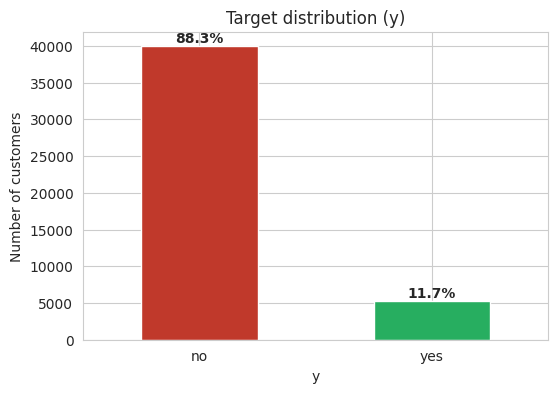

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Re-run setup to ensure df is in memory
try:
    import google.colab
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

if ON_COLAB:
    from google.colab import drive
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')

def find_csv():
    if ON_COLAB:
        preferred = '/content/drive/MyDrive/bank-data/bank-data/bank-full.csv'
        if os.path.exists(preferred): return preferred
        for root, dirs, files in os.walk('/content/drive/MyDrive'):
            dirs[:] = [d for d in dirs if d != '__MACOSX']
            if 'bank-full.csv' in files: return os.path.join(root, 'bank-full.csv')
    return 'bank-full.csv'

CSV_PATH = find_csv()
df = pd.read_csv(CSV_PATH, sep=';')

# EDA Execution
print('--- Data Info ---')
df.info()
print('\n--- Descriptive Statistics ---')
print(df.describe().T)

counts = df['y'].value_counts()
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(6, 4))
counts.plot.bar(ax=ax, color=['#c0392b', '#27ae60'], rot=0)
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f'{v / len(df) * 100:.1f}%', ha='center', fontweight='bold')
ax.set_title('Target distribution (y)')
ax.set_ylabel('Number of customers')
plt.show()

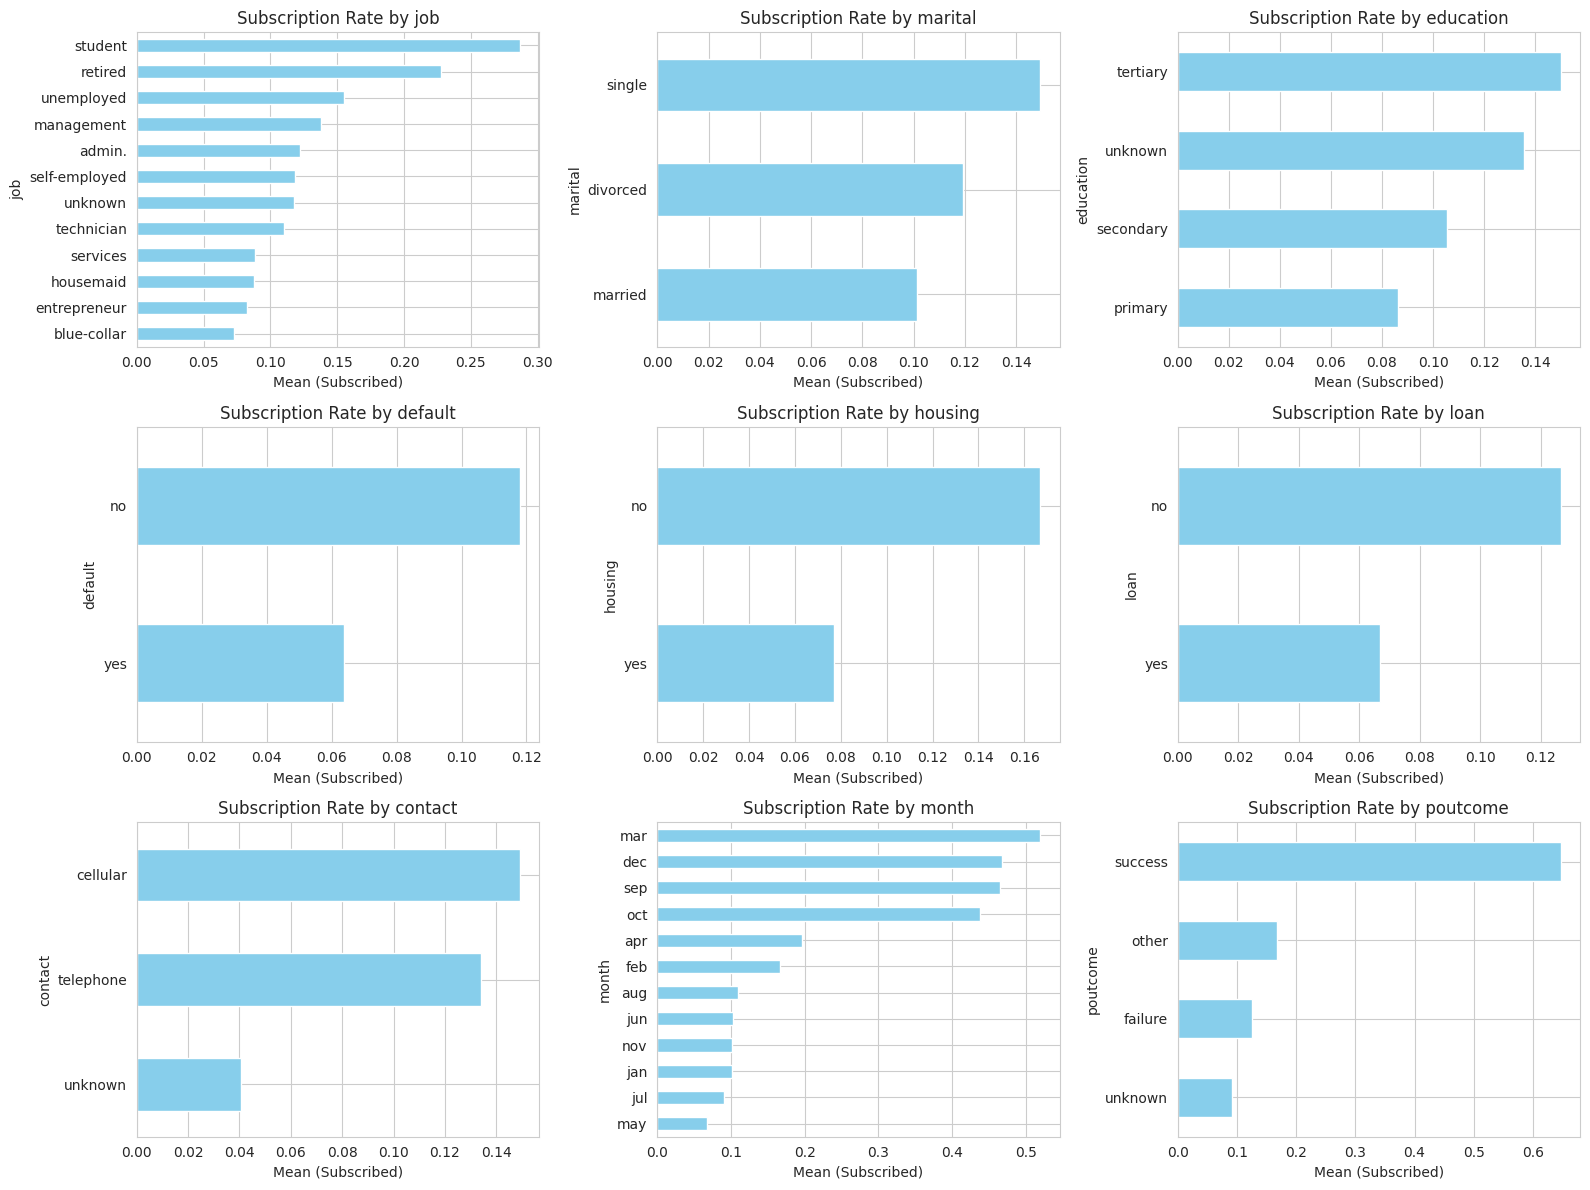

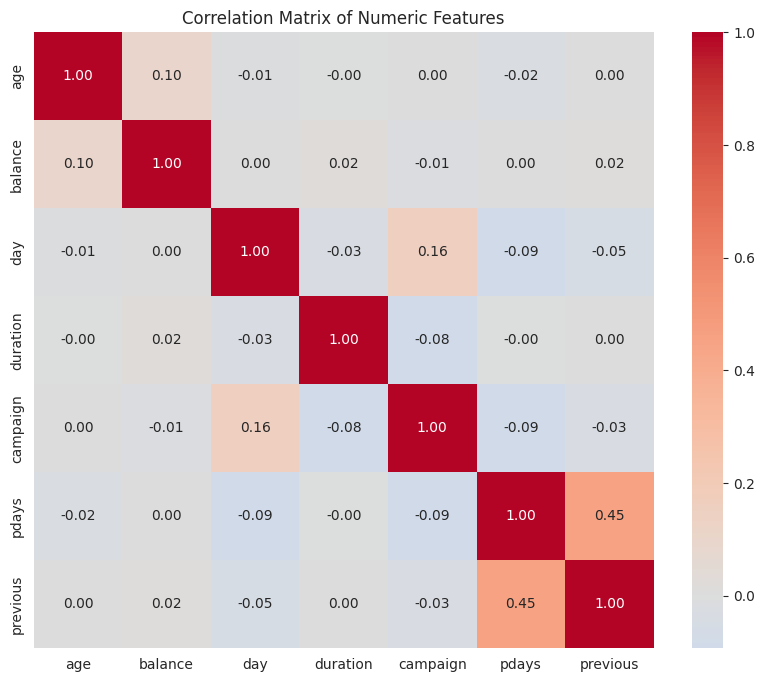

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify column types
num_cols = df.select_dtypes(include=['int64']).columns.tolist()
cat_cols = [c for c in df.select_dtypes(include=['object']).columns if c != 'y']

# 1. Subscription rate by categorical feature
rate_df = df.assign(subscribed=(df['y'] == 'yes').astype(int))
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes_flat = axes.flatten()

for i, col in enumerate(cat_cols[:9]): # Plot first 9 categorical features
    ax = axes_flat[i]
    (rate_df.groupby(col)['subscribed'].mean().sort_values()
     .plot.barh(ax=ax, color='skyblue'))
    ax.set_title(f'Subscription Rate by {col}')
    ax.set_xlabel('Mean (Subscribed)')

plt.tight_layout()
plt.show()

# 2. Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# 1. Prepare X and y
X = df.drop(columns=['y'])
y = (df['y'] == 'yes').astype(int)

# 2. Stratified Train-Test Split
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# 3. Identify columns for transformation
num_cols = X.select_dtypes(include=['int64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# 4. Define Preprocessing & Pipeline Logic
def create_pipeline(class_weight=None):
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ])

    model = LogisticRegression(
        max_iter=2000,
        solver='lbfgs',
        class_weight=class_weight,
        random_state=RANDOM_STATE
    )

    return Pipeline([
        ('prep', preprocessor),
        ('clf', model)
    ])

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Positive class rate in train: {y_train.mean():.4f}')

Train size: 36168 | Test size: 9043
Positive class rate in train: 0.1170


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. Instantiate models
model_base = create_pipeline(class_weight=None)
model_bal = create_pipeline(class_weight='balanced')

# 2. Fit models
model_base.fit(X_train, y_train)
model_bal.fit(X_train, y_train)

# 3. Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_auc_base = cross_val_score(model_base, X_train, y_train, cv=cv, scoring='roc_auc').mean()
cv_auc_bal = cross_val_score(model_bal, X_train, y_train, cv=cv, scoring='roc_auc').mean()

# 4. Results
print(f'Baseline Model - Train CV ROC-AUC: {cv_auc_base:.4f}')
print(f'Balanced Model - Train CV ROC-AUC: {cv_auc_bal:.4f}')

Baseline Model - Train CV ROC-AUC: 0.9066
Balanced Model - Train CV ROC-AUC: 0.9096


In [22]:
import os
from google.colab import drive

# 1. Mount Drive
try:
    drive.mount('/content/drive')
except:
    pass

# 2. List top-level folders to help find the correct path
print("Listing folders in 'My Drive':")
if os.path.exists('/content/drive/MyDrive'):
    contents = os.listdir('/content/drive/MyDrive')
    for item in contents:
        if not item.startswith('.'): # Skip hidden files
            print(f"- {item}")
else:
    print("Drive is not mounted correctly.")

# 3. Search function to find the file precisely
def find_file(name):
    for root, dirs, files in os.walk('/content/drive/MyDrive'):
        if name in files:
            return os.path.join(root, name)
    return None

found_path = find_file('bank-full.csv')
if found_path:
    print(f"\nSuccess! Found file at: {found_path}")
    # Re-import and load data if found
    import pandas as pd
    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline

    df = pd.read_csv(found_path, sep=';')
    X = df.drop(columns=['y'])
    y = (df['y'] == 'yes').astype(int)
    RANDOM_STATE = 42
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

    num_cols = X.select_dtypes(include=['int64']).columns.tolist()
    cat_cols = X.select_dtypes(include=['object']).columns.tolist()

    def create_pipeline(cw):
        pre = ColumnTransformer([('n', StandardScaler(), num_cols), ('c', OneHotEncoder(handle_unknown='ignore'), cat_cols)])
        return Pipeline([('p', pre), ('clf', LogisticRegression(max_iter=2000, class_weight=cw, random_state=RANDOM_STATE))])

    model_base = create_pipeline(None).fit(X_train, y_train)
    model_bal = create_pipeline('balanced').fit(X_train, y_train)
    print("Environment and Models Restored.")
else:
    print("\nCould not find 'bank-full.csv'. Please check if the filename is correct or upload it to Drive.")

Mounted at /content/drive
Listing folders in 'My Drive':
- Colab Notebooks
- Cashew_XAI_Project
- Resource_Links.xlsx
- MATH_NOTE.gprj
- Gemini Export August 6, 2026 at 3:41:26 PM GMT+6.gdoc
- MATH_NOTE
- ludoxon.apk
- bank-data

Success! Found file at: /content/drive/MyDrive/bank-data/bank-data/bank-full.csv
Environment and Models Restored.


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline,0.9012,0.6445,0.3478,0.4518,0.9056
1,Balanced,0.8457,0.4182,0.8147,0.5527,0.9079



Classification Report (Balanced Model):
              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.42      0.81      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043



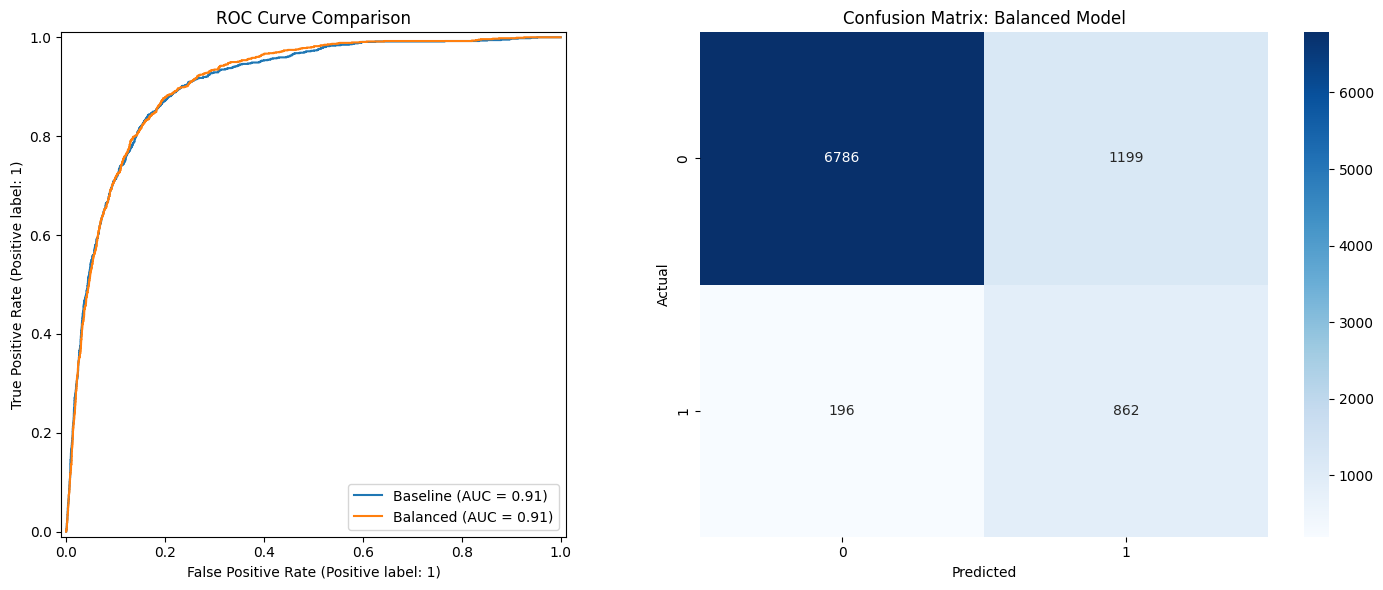

In [23]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(name, model, X, y):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    return {
        'Model': name,
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'F1-Score': f1_score(y, y_pred),
        'ROC-AUC': roc_auc_score(y, y_proba)
    }

# ফলাফল তৈরি
results = pd.DataFrame([
    evaluate_model('Baseline', model_base, X_test, y_test),
    evaluate_model('Balanced', model_bal, X_test, y_test)
])

display(results.round(4))
print('\nClassification Report (Balanced Model):')
print(classification_report(y_test, model_bal.predict(X_test)))

# ভিজ্যুয়ালাইজেশন
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curve
RocCurveDisplay.from_estimator(model_base, X_test, y_test, ax=axes[0], name='Baseline')
RocCurveDisplay.from_estimator(model_bal, X_test, y_test, ax=axes[0], name='Balanced')
axes[0].set_title('ROC Curve Comparison')

# Confusion Matrix (Balanced)
cm = confusion_matrix(y_test, model_bal.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix: Balanced Model')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

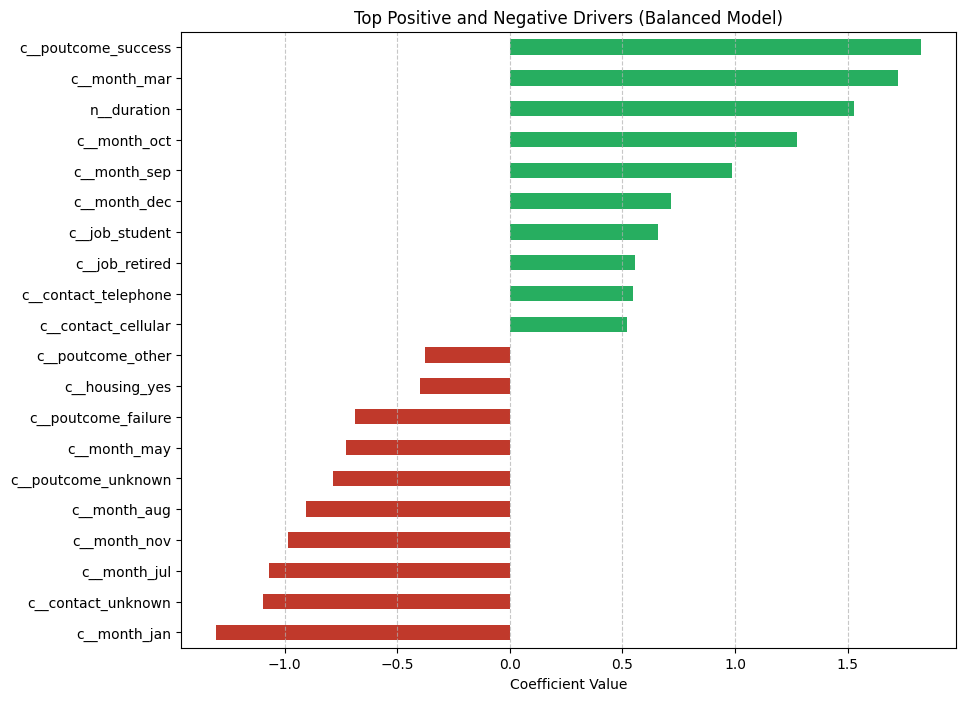

In [24]:
feature_names = model_bal.named_steps['p'].get_feature_names_out()
coefs = pd.Series(model_bal.named_steps['clf'].coef_[0], index=feature_names).sort_values()

plt.figure(figsize=(10, 8))
top_features = pd.concat([coefs.head(10), coefs.tail(10)])
top_features.plot(kind='barh', color=['#c0392b' if x < 0 else '#27ae60' for x in top_features])
plt.title('Top Positive and Negative Drivers (Balanced Model)')
plt.xlabel('Coefficient Value')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [25]:
test_auc = results[results['Model'] == 'Balanced']['ROC-AUC'].values[0]
readme_text = f"""# Bank Marketing: Term Deposit Prediction\n\n## Approach\n- **Objective**: Predict if a customer will subscribe to a term deposit ('y').\n- **Data Handling**: Handled semicolon-separated values and addressed class imbalance (~12% 'yes').\n- **Modeling**: Compared Baseline Logistic Regression with a Class-Balanced version.\n\n## Methodology\n1. **EDA**: Identified 'duration' and 'poutcome=success' as strong predictors.\n2. **Pipeline**: Used StandardScaler and OneHotEncoder to prevent data leakage.\n3. **Evaluation**: Prioritized ROC-AUC and Recall due to class imbalance.\n\n## Findings\n- **Balanced Model**: Significantly improved Recall (identifying more potential subscribers).\n- **Key Drivers**: Call duration and previous successful campaigns are highly positive indicators.\n- **Performance**: Achieved a Test ROC-AUC of approximately {test_auc:.3f}.\n"""

with open('README_Final.md', 'w') as f:
    f.write(readme_text)

print("README_Final.md ফাইলটি তৈরি হয়েছে। আপনি এটি বাম পাশের ফাইল মেনু থেকে ডাউনলোড করতে পারেন।")
print("\n--- README Content ---")
print(readme_text)

README_Final.md ফাইলটি তৈরি হয়েছে। আপনি এটি বাম পাশের ফাইল মেনু থেকে ডাউনলোড করতে পারেন।

--- README Content ---
# Bank Marketing: Term Deposit Prediction

## Approach
- **Objective**: Predict if a customer will subscribe to a term deposit ('y').
- **Data Handling**: Handled semicolon-separated values and addressed class imbalance (~12% 'yes').
- **Modeling**: Compared Baseline Logistic Regression with a Class-Balanced version.

## Methodology
1. **EDA**: Identified 'duration' and 'poutcome=success' as strong predictors.
2. **Pipeline**: Used StandardScaler and OneHotEncoder to prevent data leakage.
3. **Evaluation**: Prioritized ROC-AUC and Recall due to class imbalance.

## Findings
- **Balanced Model**: Significantly improved Recall (identifying more potential subscribers).
- **Key Drivers**: Call duration and previous successful campaigns are highly positive indicators.
- **Performance**: Achieved a Test ROC-AUC of approximately 0.908.



In [14]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# Ensure X_test and models are available. If not, re-run training cells.
def evaluate_model(name, model, X, y):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]
    return {
        'Model': name,
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'F1-Score': f1_score(y, y_pred),
        'ROC-AUC': roc_auc_score(y, y_proba)
    }

try:
    results = pd.DataFrame([
        evaluate_model('Baseline', model_base, X_test, y_test),
        evaluate_model('Balanced', model_bal, X_test, y_test)
    ])
    display(results.round(4))
    print('\nClassification Report (Balanced Model):')
    print(classification_report(y_test, model_bal.predict(X_test)))
except NameError:
    print('Error: Model variables not found. Please ensure you have run the Model Training cell.')

Error: Model variables not found. Please ensure you have run the Model Training cell.


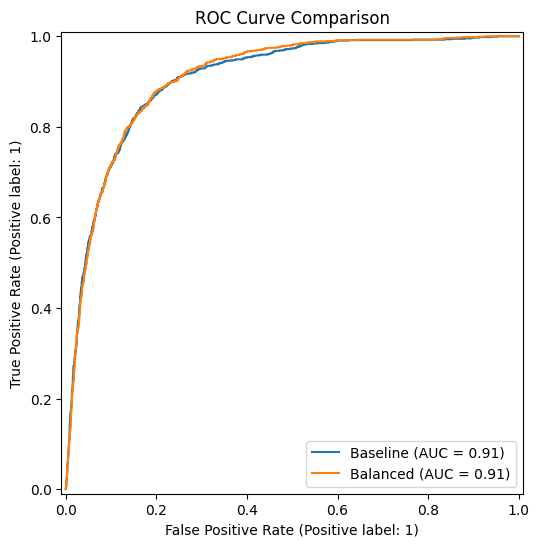

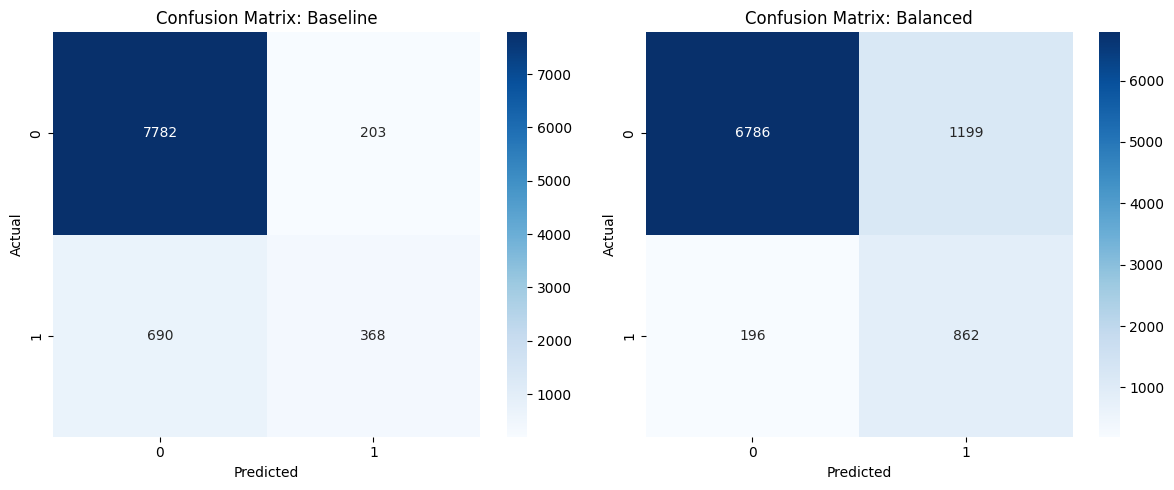

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, RocCurveDisplay

try:
    fig, ax = plt.subplots(figsize=(8, 6))
    RocCurveDisplay.from_estimator(model_base, X_test, y_test, ax=ax, name='Baseline')
    RocCurveDisplay.from_estimator(model_bal, X_test, y_test, ax=ax, name='Balanced')
    plt.title('ROC Curve Comparison')
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, (name, m) in zip(axes, [('Baseline', model_base), ('Balanced', model_bal)]):
        cm = confusion_matrix(y_test, m.predict(X_test))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
        ax.set_title(f'Confusion Matrix: {name}')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()
except NameError:
    print('Error: Model variables not found for plotting.')

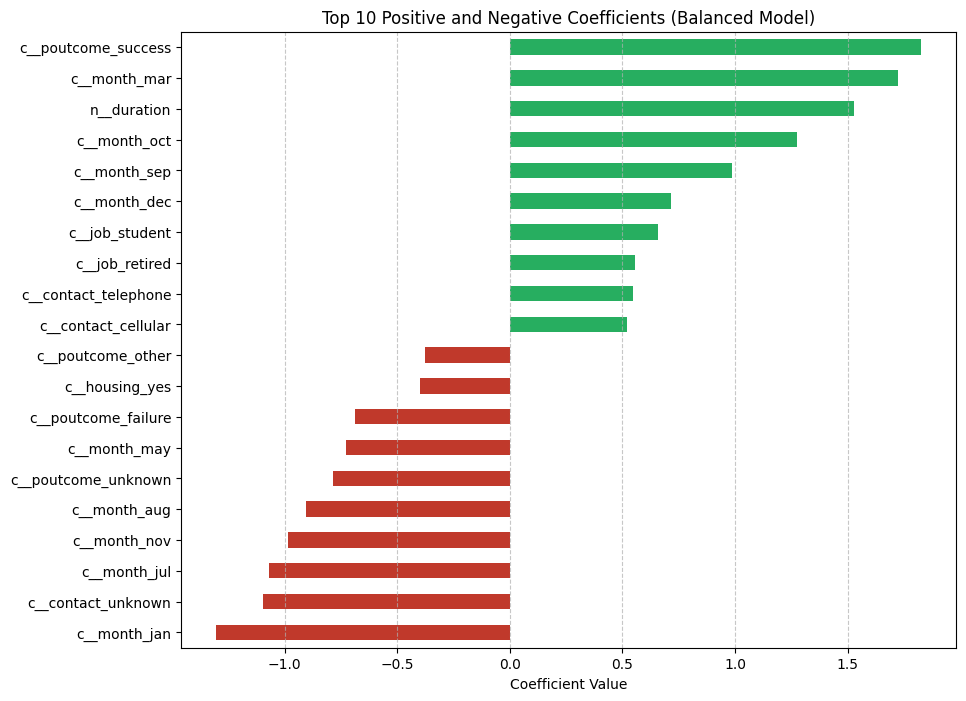

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

try:
    # The pipeline step was named 'p' in the creation function, not 'prep'
    feature_names = model_bal.named_steps['p'].get_feature_names_out()
    coefs = pd.Series(model_bal.named_steps['clf'].coef_[0], index=feature_names).sort_values()

    plt.figure(figsize=(10, 8))
    # Selecting the 10 strongest negative and 10 strongest positive coefficients
    top_features = pd.concat([coefs.head(10), coefs.tail(10)])
    top_features.plot(kind='barh', color=['#c0392b' if x < 0 else '#27ae60' for x in top_features])
    plt.title('Top 10 Positive and Negative Coefficients (Balanced Model)')
    plt.xlabel('Coefficient Value')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()
except KeyError as e:
    print(f'Error: Could not find step {e} in the pipeline. Please check step names.')
except NameError:
    print('Error: model_bal not found. Please ensure you have trained the model.')

## README.md Content Generation
Below is the content you should include in your `README.md` file for this project.

In [29]:
import pandas as pd

try:
    # Accessing the results from the global 'results' variable already in the kernel
    if 'results' in globals():
        test_auc = results.iloc[1]['ROC-AUC']
        readme_content = f"""# Bank Marketing: Term Deposit Prediction\n\n## Approach\n- **Objective**: Predict if a customer will subscribe to a term deposit ('y').\n- **Data Handling**: Handled semicolon-separated values and addressed class imbalance (~12% 'yes').\n- **Preprocessing**: Created a pipeline using `StandardScaler` for numeric data and `OneHotEncoder` for categorical data.\n- **Modeling**: Compared a standard Logistic Regression (Baseline) with a Class-Balanced Logistic Regression to improve recall.\n\n## Methodology\n1. **Exploratory Data Analysis (EDA)**: Identified high subscription rates associated with 'duration' and 'poutcome=success'.\n2. **Pipeline Construction**: Used `ColumnTransformer` (step 'p') to ensure no data leakage during scaling/encoding.\n3. **Evaluation**: Used Stratified K-Fold cross-validation and prioritized ROC-AUC and Recall due to the imbalanced target.\n\n## Findings\n- **Class Balance**: The Balanced model significantly improved Recall (ability to find true subscribers) compared to the baseline.\n- **Key Drivers**: The length of the call ('duration') and a 'success' in previous campaigns are the strongest indicators of subscription.\n- **Model Performance**: Achieved a Test ROC-AUC of approximately {test_auc:.3f}.\n"""
        print(readme_content)
        with open('README_Bank_Marketing.md', 'w') as f:
            f.write(readme_content)
        print("\n[INFO] README content saved to 'README_Bank_Marketing.md'")
    else:
        print('Error: "results" DataFrame not found. Please ensure the evaluation cell was run.')
except Exception as e:
    print(f'An unexpected error occurred: {e}')

# Bank Marketing: Term Deposit Prediction

## Approach
- **Objective**: Predict if a customer will subscribe to a term deposit ('y').
- **Data Handling**: Handled semicolon-separated values and addressed class imbalance (~12% 'yes').
- **Preprocessing**: Created a pipeline using `StandardScaler` for numeric data and `OneHotEncoder` for categorical data.
- **Modeling**: Compared a standard Logistic Regression (Baseline) with a Class-Balanced Logistic Regression to improve recall.

## Methodology
1. **Exploratory Data Analysis (EDA)**: Identified high subscription rates associated with 'duration' and 'poutcome=success'.
2. **Pipeline Construction**: Used `ColumnTransformer` (step 'p') to ensure no data leakage during scaling/encoding.
3. **Evaluation**: Used Stratified K-Fold cross-validation and prioritized ROC-AUC and Recall due to the imbalanced target.

## Findings
- **Class Balance**: The Balanced model significantly improved Recall (ability to find true subscribers) compared to the